# House Price Prediction
This notebook builds an advanced machine learning pipeline using Gradient Boosting to predict house prices based on the famous Kaggle housing dataset.

Importing the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading the Data
We load our dataset using the `pandas` library so we can view and manipulate our rows and columns.


In [2]:
df_train=pd.read_csv("train.csv")
df_test=pd.read_csv("test.csv")

Displaying the first 5 rows of the datasets

In [3]:
df_train.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Data Exploration and Information Check
Before modeling, we inspect the structural information of our data. This helps us see how many total rows we have, what columns are numbers versus text, and identify which features contain missing values (`NaN`).


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Splitting Features and Target
We isolate our target variable `y` (`SalePrice`) from our training features matrix `X` by dropping the target column.
We also drop the `Id` column from `X` because a unique tracking ID has no predictive power for house value.



In [5]:
X= df_train.drop(['SalePrice','Id'], axis=1)

In [6]:
y=df_train['SalePrice']

In [7]:
X.head(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


In [8]:
y.head(5)

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

## Visualizing the Target Variable Distribution
We load plotting tools to draw a histogram of our target variable (`y`). This lets us visually verify the spread of house prices and check if the distribution is skewed.


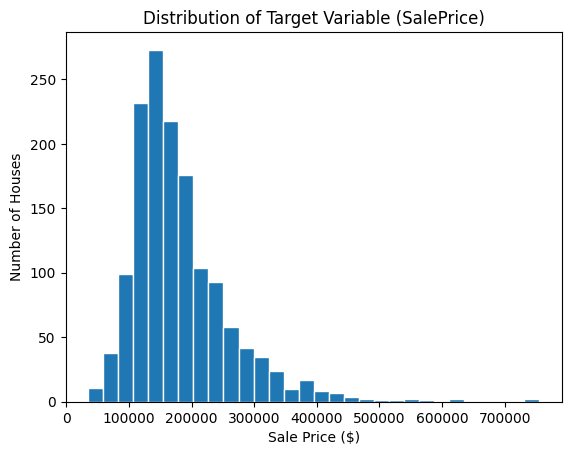

In [9]:

plt.hist(y, bins=30, edgecolor='white')

plt.xlabel('Sale Price ($)')
plt.ylabel('Number of Houses')
plt.title('Distribution of Target Variable (SalePrice)')

plt.show()


## Handling Missing Categorical Values
Before we can test different mathematical encoding techniques, we must fill in the missing text spaces (`NaN`) within our categorical columns. We will replace missing values with the most frequently occurring text option (the mode) for each column.
We import SimpleImputer which fixes the missing values,isolate just the text/object columns from our features and create a clean DataFrame copy where missing text values are completely filled



In [10]:

from sklearn.impute import SimpleImputer

categorical_cols = X.select_dtypes(include=['object']).columns

cat_imputer = SimpleImputer(strategy='most_frequent')

X_cleaned_cat = pd.DataFrame(cat_imputer.fit_transform(X[categorical_cols]), columns=categorical_cols)

print(f"Successfully cleaned missing text for {X_cleaned_cat.shape[1]} categorical columns.")


Successfully cleaned missing text for 43 categorical columns.


## Technique 1 Label Encoding
Label encoding converts unique text labels directly into sequential integer numbers (like `0, 1, 2, 3...`). This is ideal for categorical variables that have an inherent ranking or order, such as `LotShape` (Regular vs. Slightly Irregular vs. Very Irregular).


In [11]:
from sklearn.preprocessing import LabelEncoder

X_label = X_cleaned_cat.copy()

label_enc = LabelEncoder()

for col in X_label.columns:
    X_label[col] = label_enc.fit_transform(X_label[col])

X_label.head()


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,3,1,0,3,3,0,4,0,5,2,...,1,1,4,4,2,2,2,2,8,4
1,3,1,0,3,3,0,2,0,24,1,...,1,1,4,4,2,2,2,2,8,4
2,3,1,0,0,3,0,4,0,5,2,...,1,1,4,4,2,2,2,2,8,4
3,3,1,0,0,3,0,0,0,6,2,...,5,2,4,4,2,2,2,2,8,0
4,3,1,0,0,3,0,2,0,15,2,...,1,1,4,4,2,2,2,2,8,4


## Technique 2 - One-Hot Encoding
One-Hot Encoding converts each unique category into its own brand-new binary column (`0` for false, `1` for true). This prevents the model from assuming fake mathematical relationships between unrelated categories (like thinking a neighborhood encoded as `3` is inherently three times "better" than a neighborhood encoded as `1`).

* We import the OneHotEncoder tool
* Instantiate the encoder (setting sparse_output to False to easily turn it back into a DataFrame)
* Then display a preview showing the massive expansion of true/false binary fields




In [12]:

from sklearn.preprocessing import OneHotEncoder

onehot_enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_array = onehot_enc.fit_transform(X_cleaned_cat)
new_col_names = onehot_enc.get_feature_names_out(categorical_cols)

X_onehot = pd.DataFrame(encoded_array, columns=new_col_names)

print(f"One-Hot Encoding expanded our categories from {X_cleaned_cat.shape[1]} columns to {X_onehot.shape[1]} binary features!")
X_onehot.head()


One-Hot Encoding expanded our categories from 43 columns to 251 binary features!


,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_Pave,LotShape_IR1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## Creating the Preprocessing and Modeling Pipeline
Since our dataset has both numeric columns and text columns containing missing values, we load pipeline transformers. 
* **Numeric Columns:** Missing values are safely filled with the column's `median`.
* **Categorical Columns:** Missing values are filled with the `most frequent` text value, and the text values are converted into mathematical numbers using `OneHotEncoder`.
* **The Model:** We load a powerful **Gradient Boosting Regressor** as our advanced machine learning algorithm.


In [14]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor


numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])


categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
])

print("Machine learning pipeline successfully constructed!")


Machine learning pipeline successfully constructed!


## Training and Evaluating the Model
We load validation metrics. We split our dataset into a training set (80%) to teach our model, and a testing set (20%) to grade it. We fit the model and use Mean Absolute Error (MAE) to measure how close our predictions are to the actual sale prices on average.


In [15]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print(f"\nAdvanced Model Success!")
print(f"Average Prediction Error (MAE): ${mae:,.2f}")



Advanced Model Success!
Average Prediction Error (MAE): $16,552.03
